In [ ]:
# Performance config
import os

CPU_THREADS = min(32, os.cpu_count() or 32)
os.environ["OMP_NUM_THREADS"] = str(CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(CPU_THREADS)
os.environ["NUMEXPR_NUM_THREADS"] = str(CPU_THREADS)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(CPU_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "true"

REQUIRE_CUDA = True  # set False for CPU-only notebooks

print(f"CPU threads set to: {CPU_THREADS}")

try:
    import torch
except Exception as e:
    torch = None
    if REQUIRE_CUDA:
        raise RuntimeError("CUDA required but torch is not available.") from e

if torch is not None:
    torch.set_num_threads(CPU_THREADS)
    torch.set_num_interop_threads(min(4, CPU_THREADS))
    if REQUIRE_CUDA and not torch.cuda.is_available():
        raise RuntimeError("CUDA required but not available.")
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        print("CUDA device:", torch.cuda.get_device_name(0))
    else:
        print("CUDA not available; running on CPU.")


# Kvasir-VQA x1 — BLIP VQA baseline

Evaluate BLIP VQA (zero-shot) on Kvasir-VQA x1 metadata. Computes BLEU/ROUGE-L on a sample and yes/no accuracy on the yes/no subset.

In [1]:
import os
from pathlib import Path
import json
import random
import contextlib

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
from transformers import BlipProcessor, BlipForQuestionAnswering
from datasets import load_dataset
import evaluate



2026-01-14 04:02:00.275144: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-14 04:02:00.275177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-14 04:02:00.295234: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-14 04:02:00.327883: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-14 04:02:01.285777: W tensorflow/compiler/tf2

In [2]:
# Paths & config
HF_DATASET = "SimulaMet-HOST/Kvasir-VQA"  # adjust if using a different HF source

def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
META_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "metadata_enriched.csv"
OUT_DIR = DATA_ROOT / "2_modeling" / "blip_baseline" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Salesforce/blip-vqa-base"
SAMPLE_N = None  # set None for all rows (can be slow)
SAMPLE_YN = None  # yes/no subset sample
BATCH_SIZE = 96  # aggressive GPU batch; auto-reduced on CPU
SEED = 42


def pick_device():
    if not torch.cuda.is_available():
        return torch.device("cpu"), "CUDA not available; using CPU", None
    try:
        cap = torch.cuda.get_device_capability(0)
        gpu_name = torch.cuda.get_device_name(0)
        arch_list = getattr(torch.cuda, "get_arch_list", lambda: [])()
    except Exception as e:
        return torch.device("cpu"), f"CUDA check failed: {e}; using CPU", None

    def parse_arch(arch: str):
        if not arch.startswith("sm_"):
            return None
        num = arch.split("_")[1]
        if not num.isdigit():
            return None
        major = int(num[:-1]) if len(num) > 1 else int(num)
        minor = int(num[-1]) if len(num) >= 2 else 0
        return (major, minor)

    supported_caps = set(filter(None, (parse_arch(a) for a in arch_list)))
    if cap not in supported_caps:
        return torch.device("cpu"), f"GPU {gpu_name} capability {cap} unsupported by this torch build; using CPU", cap
    return torch.device("cuda"), f"CUDA available (compute capability {cap})", cap

DEVICE, DEVICE_REASON, DEVICE_CAP = pick_device()
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else None

print("Data root:", DATA_ROOT)
print("Metadata:", META_CSV)
print("Out dir:", OUT_DIR)
print("Device:", DEVICE)
if GPU_NAME:
    print("GPU:", GPU_NAME, "capability:", DEVICE_CAP)
print(DEVICE_REASON)

if DEVICE.type == "cpu":
    BATCH_SIZE = min(BATCH_SIZE, 4)
    print("CPU mode: reducing batch size to", BATCH_SIZE)
else:
    print("Using GPU batch size", BATCH_SIZE)
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True



Data root: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1
Metadata: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/0_dataset_prep/out/metadata/metadata_enriched.csv
Out dir: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/2_modeling/blip_baseline/out
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti capability: (12, 0)
CUDA available (compute capability (12, 0))
Using GPU batch size 96


In [3]:
# Runtime device sanity check
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    try:
        cap = torch.cuda.get_device_capability(0)
        name = torch.cuda.get_device_name(0)
        arch_list = getattr(torch.cuda, 'get_arch_list', lambda: [])()
        print('CUDA device:', name, 'capability:', cap)
        print('Build arch list:', arch_list)
    except Exception as e:
        print('CUDA query failed:', e)
print('Selected DEVICE:', DEVICE)


Torch: 2.10.0.dev20251208+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5070 Ti capability: (12, 0)
Build arch list: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
Selected DEVICE: cuda


In [4]:
# Load metadata
meta = pd.read_csv(META_CSV)
print("Rows:", len(meta))
print(meta.head())

# Use train/val/test if available else full set
def pick_split(df, split_name):
    if "split" in df.columns and split_name in df["split"].unique():
        return df[df["split"] == split_name].reset_index(drop=True)
    return df.reset_index(drop=True)

dev_df = pick_split(meta, "validation")
if len(dev_df) == 0:
    dev_df = pick_split(meta, "test")
if len(dev_df) == 0:
    dev_df = meta.copy()
print("Dev rows:", len(dev_df))


Rows: 58849
   split                     img_id  \
0  train  cla820gl0s3nv071u4fgd7xgq   
1  train  cla820gl0s3nv071u4fgd7xgq   
2  train  cla820gl0s3nv071u4fgd7xgq   
3  train  cla820gl0s3nv071u4fgd7xgq   
4  train  cla820gl0s3nv071u4fgd7xgq   

                                     image_path  \
0  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   
1  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   
2  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   
3  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   
4  out/images/raw/cla820gl0s3nv071u4fgd7xgq.jpg   

                                            question              answer  \
0  Are there any abnormalities in the image? Chec...  ulcerative colitis   
1  Are there any anatomical landmarks in the imag...                none   
2  Are there any instruments in the image? Check ...                none   
3                      Have all polyps been removed?        not relevant   
4                    Is this finding easy to detect?              

In [5]:
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model_kwargs = {}
if DEVICE.type == "cuda":
    model_kwargs["torch_dtype"] = torch.float16
model = BlipForQuestionAnswering.from_pretrained(MODEL_NAME, **model_kwargs)
model = model.to(DEVICE)
model.eval()
MODEL_DTYPE = next(model.parameters()).dtype
print("Loaded BLIP on", DEVICE, "dtype", MODEL_DTYPE)



Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loaded BLIP on cuda dtype torch.float16


In [6]:
# Fallback: load HF dataset and map img_id -> image if local file missing
HF_IMG_MAP = None
HF_DATASET_CACHE = None

def load_fallback_image(img_id: str):
    global HF_IMG_MAP, HF_DATASET_CACHE
    if HF_IMG_MAP is None:
        # try to load from HF
        try:
            ds_all = load_dataset(HF_DATASET)
            # pick first split
            if 'raw' in ds_all:
                ds_use = ds_all['raw']
            elif 'train' in ds_all:
                ds_use = ds_all['train']
            else:
                ds_use = list(ds_all.values())[0]
            HF_DATASET_CACHE = ds_use
            HF_IMG_MAP = {}
            for ex in ds_use:
                iid = ex.get('img_id') or ex.get('image_id') or ex.get('id') or ex.get('filename')
                if iid is None:
                    continue
                iid = str(iid).split('/')[-1].split('.')[0]
                HF_IMG_MAP[iid] = ex.get('image')
            print("Built HF image map:", len(HF_IMG_MAP))
        except Exception as e:
            print("Fallback HF load failed:", e)
            HF_IMG_MAP = {}
    return HF_IMG_MAP.get(str(img_id))


In [7]:
# Image helpers and batched generation

use_autocast = DEVICE.type == "cuda"

def get_image_for_row(row):
    img_path = Path(row["image_path"])
    if img_path.is_file():
        img = Image.open(img_path).convert("RGB")
    else:
        img_id = row.get("img_id") or img_path.stem
        img = load_fallback_image(img_id)
        if img is None:
            raise FileNotFoundError(f"Image not found locally or in HF fallback: {img_path}")
        if img.mode != "RGB":
            img = img.convert("RGB")
    return img


def batch_generate(df, batch_size=8, desc="BLIP"):
    preds = []
    refs = []
    eff_history = []
    oom_backoffs = 0
    total_steps = (len(df) + batch_size - 1) // batch_size
    for start in tqdm(range(0, len(df), batch_size), total=total_steps, desc=desc):
        eff_bs = min(batch_size, len(df) - start)
        while True:
            batch = df.iloc[start:start + eff_bs]
            images = [get_image_for_row(row) for _, row in batch.iterrows()]
            texts = [str(q) for q in batch["question"]]
            inputs = processor(images=images, text=texts, padding=True, truncation=True, return_tensors="pt").to(DEVICE)
            ctx = torch.autocast(device_type="cuda", dtype=MODEL_DTYPE) if use_autocast else contextlib.nullcontext()
            try:
                with ctx:
                    outputs = model.generate(**inputs, max_new_tokens=20)
            except torch.cuda.OutOfMemoryError:
                oom_backoffs += 1
                if eff_bs == 1:
                    raise
                eff_bs = max(1, eff_bs // 2)
                torch.cuda.empty_cache()
                continue
            decoded = processor.batch_decode(outputs, skip_special_tokens=True)
            preds.extend(decoded)
            refs.extend(batch["answer"].astype(str).tolist())
            eff_history.append(len(batch))
            break
    if len(eff_history) > 0:
        print(f"Batch stats -> min: {min(eff_history)}, max: {max(eff_history)}, mean: {sum(eff_history)/len(eff_history):.2f}, OOM backoffs: {oom_backoffs}")
    return preds, refs


# Metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")



In [8]:
# Run eval on a sample for BLEU/ROUGE

def eval_sample(df, n=None, batch_size=8):
    if n is not None:
        df = df.sample(min(n, len(df)), random_state=SEED).reset_index(drop=True)
    else:
        df = df.reset_index(drop=True)
    preds, refs = batch_generate(df, batch_size=batch_size, desc="BLIP eval")
    bleu_refs = [[r] for r in refs]  # sacrebleu expects list-of-list references
    bleu_score = bleu.compute(predictions=preds, references=bleu_refs)["bleu"]
    rouge_l = rouge.compute(predictions=preds, references=refs)["rougeL"]
    return df, preds, refs, bleu_score, rouge_l

dev_df_sampled, preds, refs, bleu_score, rouge_l = eval_sample(dev_df, n=SAMPLE_N, batch_size=BATCH_SIZE)

dev_df_sampled = dev_df_sampled.copy()
dev_df_sampled["pred_blip"] = preds

print("BLEU:", bleu_score)
print("ROUGE-L:", rouge_l)

# Save predictions
pred_path = OUT_DIR / "predictions_blip_sample.csv"
dev_df_sampled.to_csv(pred_path, index=False)
print("Saved:", pred_path)



BLIP eval:   0%|          | 0/62 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

Built HF image map: 6500
Batch stats -> min: 75, max: 96, mean: 95.66, OOM backoffs: 0
BLEU: 0.0
ROUGE-L: 0.2404937893723597
Saved: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/2_modeling/blip_baseline/out/predictions_blip_sample.csv


In [9]:
# Yes/No subset accuracy
yn_df = dev_df[dev_df["answer"].astype(str).str.lower().isin(["yes", "no"])]
if SAMPLE_YN is not None:
    yn_df = yn_df.sample(min(SAMPLE_YN, len(yn_df)), random_state=SEED).reset_index(drop=True)
else:
    yn_df = yn_df.reset_index(drop=True)

def to_yesno(text):
    t = str(text).lower()
    if "yes" in t:
        return "yes"
    if "no" in t:
        return "no"
    return "no"

yn_preds, yn_refs = batch_generate(yn_df, batch_size=BATCH_SIZE, desc="BLIP yes/no")
y_pred_labels = [to_yesno(p) for p in yn_preds]
y_true = pd.Series(yn_refs).str.lower().tolist()
acc_yn = (pd.Series(y_pred_labels) == pd.Series(y_true)).mean() if len(yn_df) else 0
print("Yes/No accuracy:", acc_yn, "(n=", len(yn_df), ")")

yn_df_out = yn_df.copy()
yn_df_out["pred_blip_yesno"] = y_pred_labels
yn_path = OUT_DIR / "predictions_blip_yesno.csv"
yn_df_out.to_csv(yn_path, index=False)
print("Saved yes/no preds:", yn_path)



BLIP yes/no:   0%|          | 0/16 [00:00<?, ?it/s]

Batch stats -> min: 84, max: 96, mean: 95.25, OOM backoffs: 0
Yes/No accuracy: 0.5479002624671916 (n= 1524 )
Saved yes/no preds: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/2_modeling/blip_baseline/out/predictions_blip_yesno.csv


## Notes
- Adjust `SAMPLE_N` / `SAMPLE_YN` to control runtime (set to None for full eval).
- BLEU/ROUGE are on the sampled set; yes/no accuracy is on the yes/no subset.
- Use results to decide if fine-tuning or constrained decoding is needed.


Exact match (sample): 0.21497218007081437


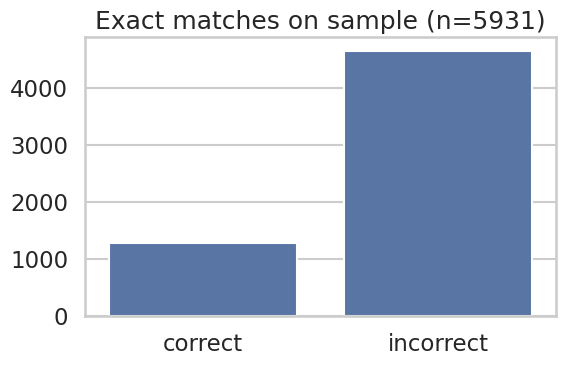

/tmp/ipykernel_2089773/2421061046.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


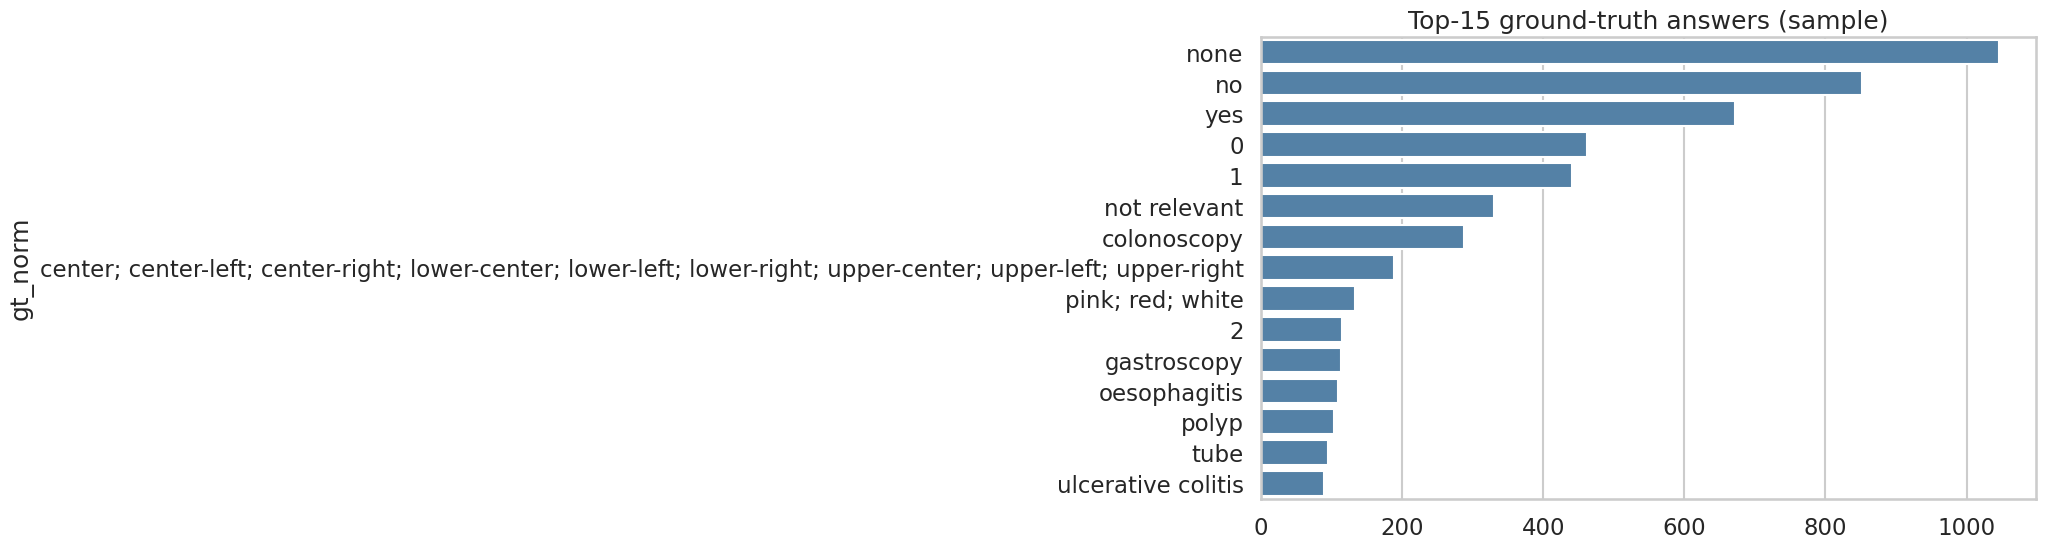

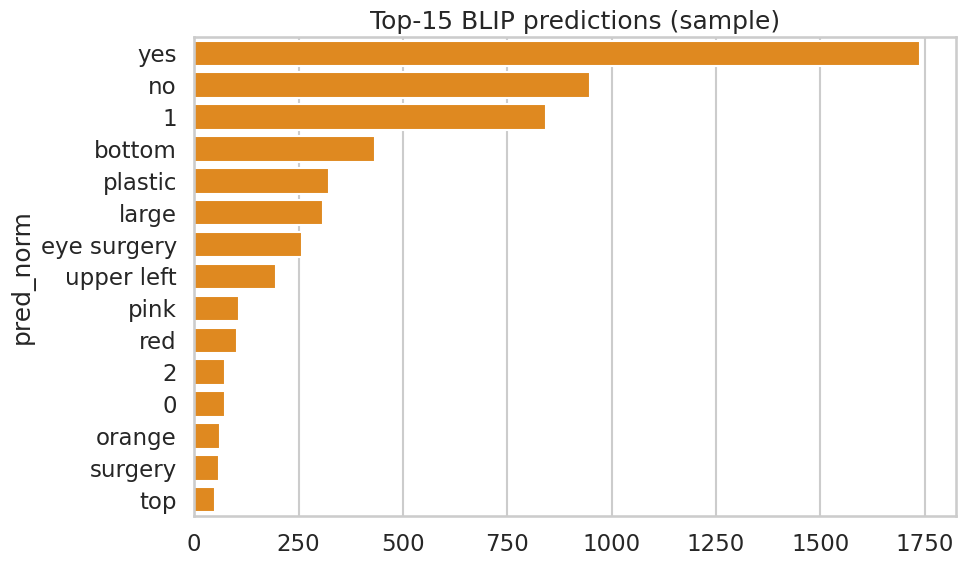

/tmp/ipykernel_2089773/2421061046.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=acc_per_ans.index, x=acc_per_ans.values, palette="viridis")
/tmp/ipykernel_2089773/2421061046.py:60: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


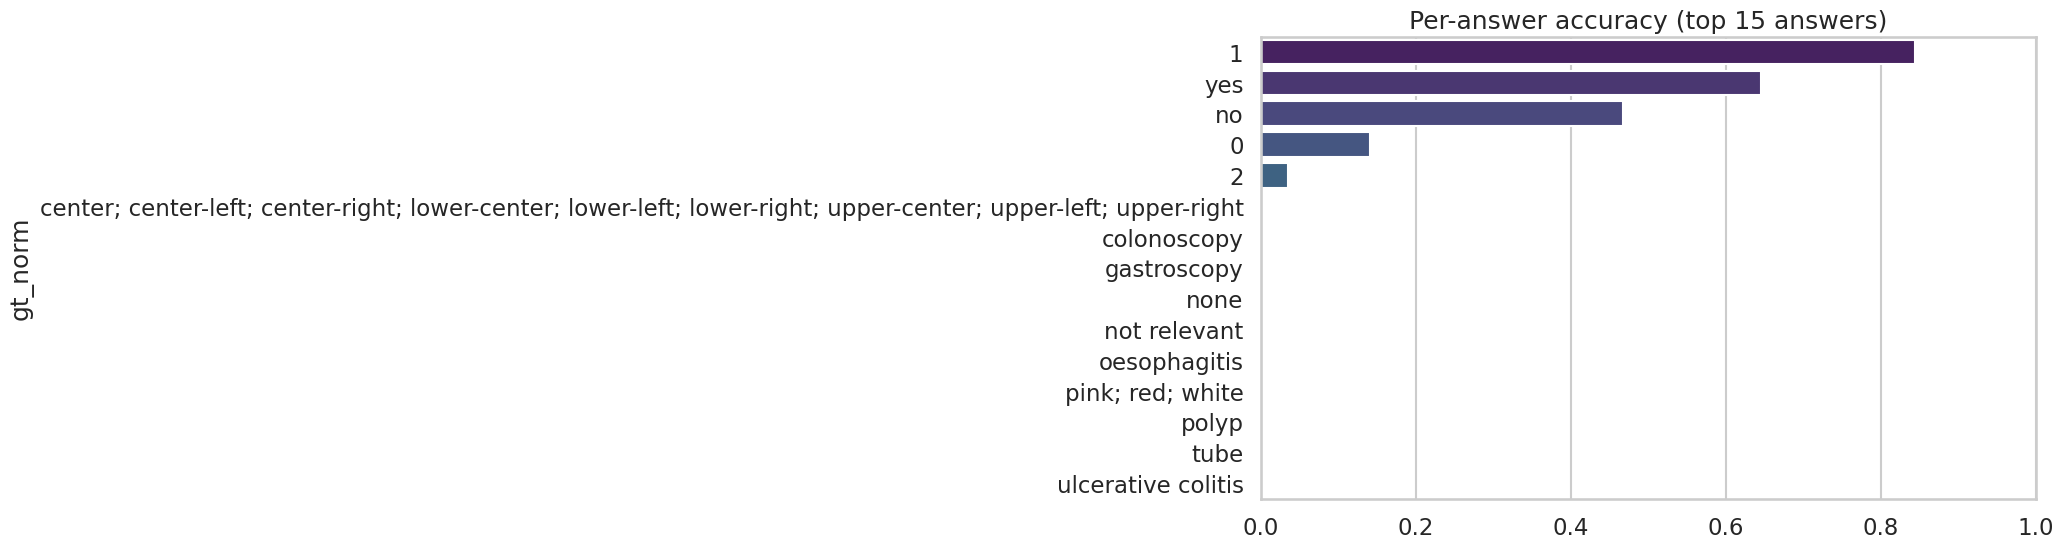

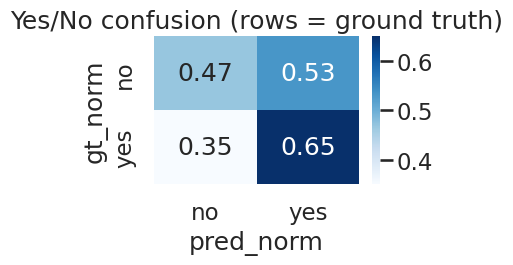

In [10]:
# Visualize BLIP predictions vs ground truth
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="talk", style="whitegrid")

base = OUT_DIR
sample_path = base / "predictions_blip_sample.csv"
yn_path = base / "predictions_blip_yesno.csv"

sample_df = pd.read_csv(sample_path)
yn_df = pd.read_csv(yn_path)

out_dir = base
out_dir.mkdir(exist_ok=True, parents=True)

norm = lambda s: str(s).strip().lower()

# Exact match
sample_df["gt_norm"] = sample_df["answer"].apply(norm)
sample_df["pred_norm"] = sample_df["pred_blip"].apply(norm)
sample_df["correct"] = sample_df["gt_norm"] == sample_df["pred_norm"]
print("Exact match (sample):", sample_df["correct"].mean())

plt.figure(figsize=(6,4))
sns.barplot(x=["correct","incorrect"], y=[sample_df["correct"].sum(), (~sample_df["correct"]).sum()])
plt.title(f"Exact matches on sample (n={len(sample_df)})")
plt.tight_layout()
plt.savefig(out_dir / "blip_sample_exact_match.png", dpi=200)
plt.show()

# Top answers
plt.figure(figsize=(10,6))
sns.barplot(y=sample_df["gt_norm"].value_counts().head(15).index,
            x=sample_df["gt_norm"].value_counts().head(15).values,
            color="steelblue")
plt.title("Top-15 ground-truth answers (sample)")
plt.tight_layout()
plt.savefig(out_dir / "blip_sample_top_gt.png", dpi=200)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(y=sample_df["pred_norm"].value_counts().head(15).index,
            x=sample_df["pred_norm"].value_counts().head(15).values,
            color="darkorange")
plt.title("Top-15 BLIP predictions (sample)")
plt.tight_layout()
plt.savefig(out_dir / "blip_sample_top_pred.png", dpi=200)
plt.show()

# Per-answer accuracy for frequent answers
freq = sample_df["gt_norm"].value_counts()
top_answers = freq.head(15).index
acc_per_ans = (sample_df[sample_df["gt_norm"].isin(top_answers)]
               .groupby("gt_norm")["correct"].mean().sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot(y=acc_per_ans.index, x=acc_per_ans.values, palette="viridis")
plt.title("Per-answer accuracy (top 15 answers)")
plt.xlim(0,1)
plt.tight_layout()
plt.savefig(out_dir / "blip_sample_per_answer_acc.png", dpi=200)
plt.show()

# Yes/No confusion
yn_df["gt_norm"] = yn_df["answer"].apply(norm)
yn_df["pred_norm"] = yn_df["pred_blip_yesno"].apply(norm)
cm = pd.crosstab(yn_df["gt_norm"], yn_df["pred_norm"], normalize="index")
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Yes/No confusion (rows = ground truth)")
plt.tight_layout()
plt.savefig(out_dir / "blip_yesno_confusion.png", dpi=200)
plt.show()

